In [1]:
import kagglehub
path = kagglehub.dataset_download("alehcleal/ferrari-stock-data-2015-2026")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import numpy as np


In [3]:
import os
print(os.listdir(path))

['Ferrari History Stock Data.csv']


In [4]:
df = pd.read_csv(os.path.join(path, 'Ferrari History Stock Data.csv'))
df.head()

,Date,Close,High,Low,Open,Volume
0,2015-10-21,50.845524,56.364575,50.845524,55.467844,22498800
1,2015-10-22,52.463337,53.803811,51.492650,52.759165,4545100
2,2015-10-23,52.121284,53.618915,52.019593,53.406289,1967600
3,2015-10-26,50.864014,52.694452,50.420271,52.694452,1466300
4,2015-10-27,49.782391,50.836283,45.631549,50.660632,5949200


In [5]:
df.shape

(2598, 6)

In [6]:
org_df=df

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# plt.figure(figsize=(14, 7))
# sns.lineplot(x='Date', y='Close', data=df)
# plt.title('Trading close Over Time')
# plt.xlabel('Date')
# plt.ylabel('Close')
# plt.grid(True)
# plt.show()

In [9]:
# df.drop(['Date'],axis=1,inplace=True)

In [10]:
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['EMA10'] = df['Close'].ewm(span=10, adjust=False).mean()
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()
# RSI

delta = df['Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))


df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)

In [11]:
df = df.dropna()

In [12]:
X = df[[
        'MA10','MA20',
        'EMA10','EMA20',
        'RSI',
        'Lag1','Lag2','Lag3']]

y = df['Close']

In [13]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
import pickle

lr_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

pickle.dump(lr_pipeline, open("lr_pipeline.pkl", "wb"))

In [15]:
lr_pipeline.predict(X_test)

array([339.46955024, 376.99691608, 375.59571   , 368.60177185,
       364.18229984, 375.76907341, 381.7210098 , 385.46308946,
       380.58539261, 369.12972781, 368.27634606, 383.74669495,
       388.855441  , 385.38683326, 393.63258449, 403.45607847,
       408.7886353 , 412.31770821, 415.13924433, 420.79816128,
       417.55231324, 419.20264331, 407.72295498, 404.61294464,
       408.26317925, 416.08262754, 414.70435858, 406.39185921,
       414.81544947, 417.94290049, 418.68658079, 420.00265258,
       421.81905863, 425.93372749, 425.62252686, 424.03754846,
       425.79643852, 431.33838046, 433.06093753, 433.68237637,
       429.38426387, 427.05373438, 415.23743982, 415.25988894,
       411.38139162, 415.33761903, 416.63330369, 414.52592041,
       412.01959728, 413.58146086, 408.11928852, 408.49995357,
       407.22565289, 412.20320399, 405.82431699, 400.39440238,
       403.77987439, 419.29479082, 418.94086471, 411.26667193,
       416.12484821, 420.71998074, 416.19332726, 412.73

In [16]:
y_test

2082    340.997681
2083    383.908295
2084    373.853424
2085    366.371399
2086    373.143646
           ...    
2593    379.079987
2594    374.989990
2595    366.429993
2596    366.500000
2597    366.950012
Name: Close, Length: 516, dtype: float64

In [17]:
from sklearn.metrics import mean_squared_error,r2_score

In [18]:
r2_score(y_test,lr_pipeline.predict(X_test))

0.9942644643674137

In [19]:
mean_squared_error(y_test,lr_pipeline.predict(X_test))

9.478437177384933

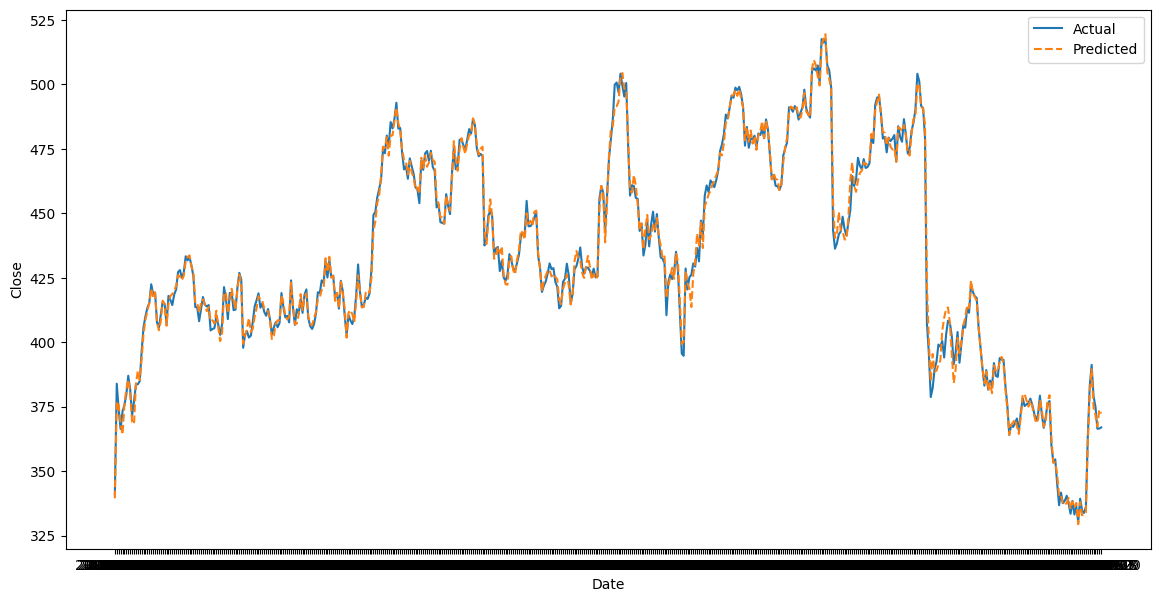

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))
sns.lineplot(x=df['Date'][split:], y=y_test, label="Actual")
sns.lineplot(x=df['Date'][split:], y=lr_pipeline.predict(X_test), label="Predicted", linestyle='--')
plt.legend()
plt.show()

In [24]:
# from xgboost import XGBRegressor
# xgb_pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('model', XGBRegressor())
# ])


# xgb_pipeline.fit(X_train, y_train)

# pickle.dump(lr_pipeline, open("lr_pipeline.pkl", "wb"))

In [25]:
# r2_score(y_test,xgb_pipeline.predict(X_test))